>>> Processing files for all cases...

-> Extracting: No DC

-> Extracting: ASE + Evap. Cooling

-> Extracting: ASE + Air Chillers


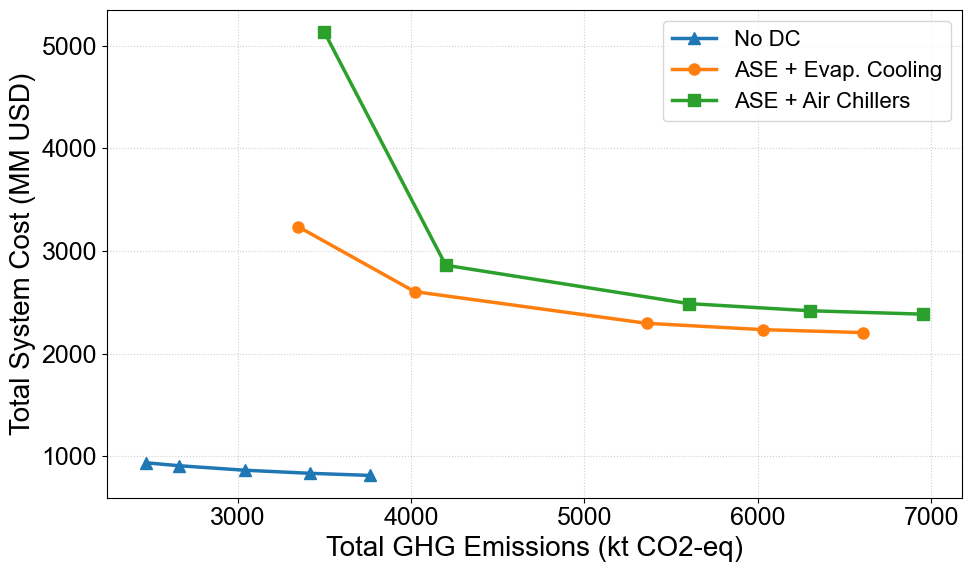

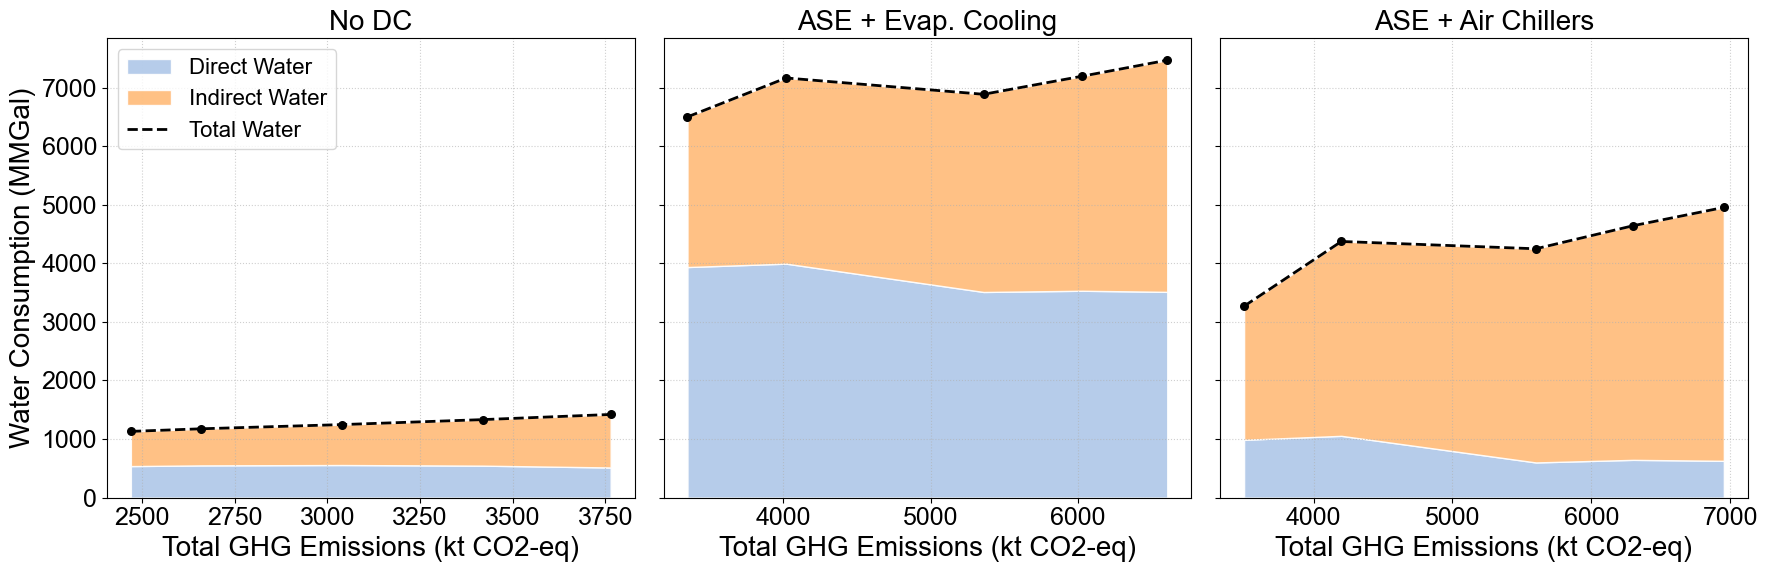

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
# Easily change any font size here!
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 16,
    "title_size"    => 20,  # Size for plot titles
    "axis_label"    => 20,  # Size for X and Y axis text
    "tick_label"    => 18,  # Size for numbers on the axes
    "legend_size"   => 16   # Size for legend text
)

# Apply Plotting Styles globally (kept as a fallback)
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# Define the 3 Cases with their specific paths, files, and assigned colors
cases = [
    ("No DC", "../Emission_Cost_Pareto_Case_No_DC/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_2_90pct.xlsx",
        "Results_Pareto_3_80pct.xlsx",
        "Results_Pareto_4_70pct.xlsx",
        "Results_Pareto_5_65pct.xlsx"
    ], "#1f77b4", "^"), # Blue, Triangle

    ("ASE + Evap. Cooling", "./", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#ff7f0e", "o"), # Orange, Circle

    ("ASE + Air Chillers", "../Emission_Cost_Pareto_Case_6/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#2ca02c", "s")  # Green, Square
]

# Dictionary to store the extracted data for each case
results_data = Dict{String, DataFrame}()

# ==========================================
# 2. Data Extraction Logic
# ==========================================
println(">>> Processing files for all cases...")

for (case_name, dir_path, fnames, color, marker) in cases
    df_results = DataFrame(
        Emissions = Float64[], 
        Cost = Float64[], 
        Water_Total = Float64[], 
        Water_Direct = Float64[], 
        Water_Indirect = Float64[]
    )
    
    println("\n-> Extracting: $case_name")
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        if !isfile(filepath)
            println("   ⚠️ Warning: File not found: $filepath")
            continue
        end

        xf = XLSX.readxlsx(filepath)

        # --- A. EMISSIONS ---
        sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
        
        val_emi = !isnothing(total_row_idx) ? 
            (sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]) : 
            (sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4]))

        # --- B. COSTS ---
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        
        val_cost = !isnothing(total_row_cost_idx) ? 
            (sh_cost[total_row_cost_idx, 2] + sh_cost[total_row_cost_idx, 3] + sh_cost[total_row_cost_idx, 4] + sh_cost[total_row_cost_idx, 5]) : 
            (sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + sum(sh_cost[!, 4]) + sum(sh_cost[!, 5]))

        # --- C. WATER ---
        sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        
        function get_col_sum(df, name_part)
            c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
            return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
        end

        val_indirect = get_col_sum(sh_water, "Grid_Indirect")
        direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
        val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
        
        push!(df_results, (val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    end
    
    # Sort Ascending by Emissions (Crucial for proper stackplot and line plotting)
    sort!(df_results, :Emissions)
    results_data[case_name] = df_results
end

# ==========================================
# 3. Find Global Max for Water Y-Axis
# ==========================================
global_max_water = 0.0
for (case_name, df) in results_data
    if nrow(df) > 0
        global_max_water = max(global_max_water, maximum(df.Water_Total))
    end
end
water_ylim_max = global_max_water * 1.05

# ==========================================
# 4. PLOTTING FIGURE 1: 1x1 Pareto Front
# ==========================================
fig1, ax_pareto = PyPlot.subplots(1, 1, figsize=(10, 6))

for (case_name, _, _, color, marker) in cases
    if haskey(results_data, case_name) && nrow(results_data[case_name]) > 0
        df = results_data[case_name]
        ax_pareto.plot(df.Emissions, df.Cost, marker=marker, linestyle="-", 
                       color=color, markersize=8, linewidth=2.5, label=case_name)
    end
end

# EXPLICITLY set font sizes for Pareto Front
ax_pareto.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=style["axis_label"])
ax_pareto.set_ylabel("Total System Cost (MM USD)", fontsize=style["axis_label"])
ax_pareto.tick_params(axis="both", labelsize=style["tick_label"])
ax_pareto.legend(loc="upper right", fontsize=style["legend_size"])
ax_pareto.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
# savefig("Pareto_Front.pdf", dpi=600, bbox_inches="tight")

display(fig1)

# ==========================================
# 5. PLOTTING FIGURE 2: 1x3 Water Trade-offs
# ==========================================
# sharey=true ensures the Y-axis limits match automatically and removes redundant axis text
fig2, axs_water = PyPlot.subplots(1, 3, figsize=(18, 6), sharey=true)

# Helper function for the 1x3 water plots
function plot_water_tradeoff!(ax, case_name, df, y_max, show_ylabel=false, show_legend=false)
    if nrow(df) == 0; return; end
    
    ax.stackplot(df.Emissions, df.Water_Direct, df.Water_Indirect, 
                 labels=["Direct Water", "Indirect Water"], colors=["#aec7e8", "#ffbb78"], alpha=0.9, edgecolor="white")
                 
    ax.plot(df.Emissions, df.Water_Total, color="black", linestyle="--", linewidth=2, label="Total Water")
    ax.scatter(df.Emissions, df.Water_Total, color="black", s=30, zorder=5)

    # EXPLICITLY set font sizes for Water Trade-offs
    ax.set_title(case_name, fontsize=style["title_size"])
    ax.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=style["axis_label"])
    
    # Only label the Y-axis on the leftmost plot
    if show_ylabel
        ax.set_ylabel("Water Consumption (MMGal)", fontsize=style["axis_label"])
    end
    
    ax.tick_params(axis="both", labelsize=style["tick_label"])
    ax.set_ylim(0, y_max)
    
    # Only draw the legend if show_legend is true
    if show_legend
        ax.legend(loc="upper left", fontsize=style["legend_size"])
    end
    
    ax.grid(true, linestyle=":", alpha=0.6)
end

# Plot each case into the 1x3 grid
plot_water_tradeoff!(axs_water[1], cases[1][1], results_data[cases[1][1]], water_ylim_max, true, true)    # No DC (Show Y-label & Legend)
plot_water_tradeoff!(axs_water[2], cases[2][1], results_data[cases[2][1]], water_ylim_max, false, false)  # ASE + Evap (Hide both)
plot_water_tradeoff!(axs_water[3], cases[3][1], results_data[cases[3][1]], water_ylim_max, false, false)  # ASE + Air (Hide both)

PyPlot.tight_layout()
# savefig("Water_Tradeoffs.pdf", dpi=600, bbox_inches="tight")
display(fig2)

>>> Processing files for all cases...

-> Extracting: ASE + Evap. Cooling

-> Extracting: ASE + Air Chillers


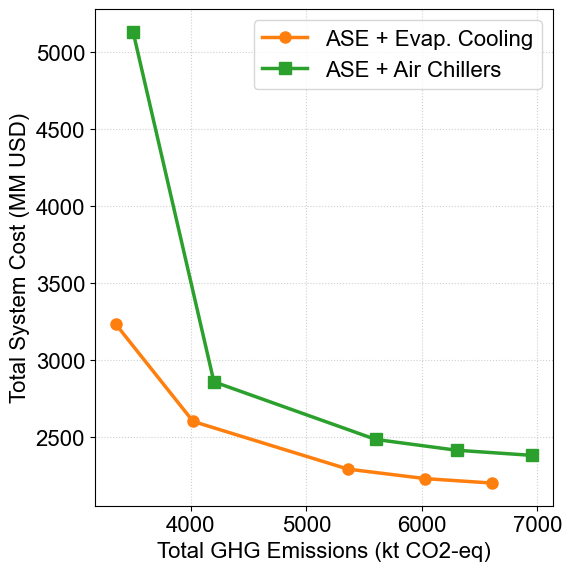

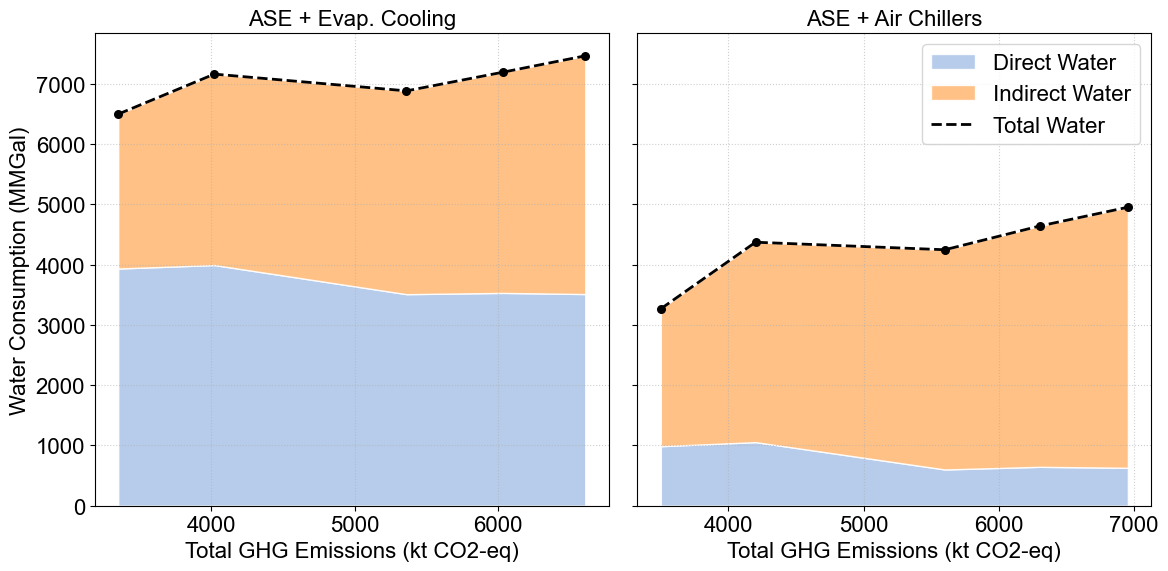

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 16,
    "title_size"    => 16,
    "axis_label"    => 16,
    "tick_label"    => 16,
    "legend_size"   => 16
)

# Apply Plotting Styles globally
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# Define the 2 remaining Cases
cases = [
    ("ASE + Evap. Cooling", "./", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#ff7f0e", "o"), # Orange, Circle

    ("ASE + Air Chillers", "../Emission_Cost_Pareto_Case_6/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#2ca02c", "s")  # Green, Square
]

results_data = Dict{String, DataFrame}()

# ==========================================
# 2. Data Extraction Logic
# ==========================================
println(">>> Processing files for all cases...")

for (case_name, dir_path, fnames, color, marker) in cases
    df_results = DataFrame(
        Emissions = Float64[], 
        Cost = Float64[], 
        Water_Total = Float64[], 
        Water_Direct = Float64[], 
        Water_Indirect = Float64[]
    )
    
    println("\n-> Extracting: $case_name")
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        if !isfile(filepath)
            println("   ⚠️ Warning: File not found: $filepath")
            continue
        end

        xf = XLSX.readxlsx(filepath)

        # --- A. EMISSIONS ---
        sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
        
        val_emi = !isnothing(total_row_idx) ? 
            (sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]) : 
            (sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4]))

        # --- B. COSTS ---
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        
        val_cost = !isnothing(total_row_cost_idx) ? 
            (sh_cost[total_row_cost_idx, 2] + sh_cost[total_row_cost_idx, 3] + sh_cost[total_row_cost_idx, 4] + sh_cost[total_row_cost_idx, 5]) : 
            (sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + sum(sh_cost[!, 4]) + sum(sh_cost[!, 5]))

        # --- C. WATER ---
        sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        
        function get_col_sum(df, name_part)
            c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
            return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
        end

        val_indirect = get_col_sum(sh_water, "Grid_Indirect")
        direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
        val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
        
        push!(df_results, (val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    end
    
    sort!(df_results, :Emissions)
    results_data[case_name] = df_results
end

# ==========================================
# 3. Find Global Max for Water Y-Axis
# ==========================================
global_max_water = 0.0
for (case_name, df) in results_data
    if nrow(df) > 0
        global_max_water = max(global_max_water, maximum(df.Water_Total))
    end
end
water_ylim_max = global_max_water * 1.05

# ==========================================
# 4. PLOTTING FIGURE 1: Pareto Front
# ==========================================
fig1, ax_pareto = PyPlot.subplots(1, 1, figsize=(6, 6))

for (case_name, _, _, color, marker) in cases
    if haskey(results_data, case_name) && nrow(results_data[case_name]) > 0
        df = results_data[case_name]
        ax_pareto.plot(df.Emissions, df.Cost, marker=marker, linestyle="-", 
                       color=color, markersize=8, linewidth=2.5, label=case_name)
    end
end

ax_pareto.set_xlabel("Total GHG Emissions (kt CO2-eq)")
ax_pareto.set_ylabel("Total System Cost (MM USD)")
ax_pareto.legend(loc="upper right")
ax_pareto.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
# savefig("abstract_Pareto_Front.pdf", dpi=600, bbox_inches="tight")
display(fig1)

# ==========================================
# 5. PLOTTING FIGURE 2: 1x2 Water Trade-offs
# ==========================================
fig2, axs_water = PyPlot.subplots(1, 2, figsize=(12, 6), sharey=true)

function plot_water_tradeoff!(ax, case_name, df, y_max, show_ylabel=false, show_legend=false)
    if nrow(df) == 0; return; end
    
    ax.stackplot(df.Emissions, df.Water_Direct, df.Water_Indirect, 
                 labels=["Direct Water", "Indirect Water"], colors=["#aec7e8", "#ffbb78"], alpha=0.9, edgecolor="white")
                 
    ax.plot(df.Emissions, df.Water_Total, color="black", linestyle="--", linewidth=2, label="Total Water")
    ax.scatter(df.Emissions, df.Water_Total, color="black", s=30, zorder=5)

    ax.set_title(case_name)
    ax.set_xlabel("Total GHG Emissions (kt CO2-eq)")
    
    if show_ylabel
        ax.set_ylabel("Water Consumption (MMGal)")
    end
    
    ax.set_ylim(0, y_max)
    if show_legend
        ax.legend(loc="upper right")
    end
    
    ax.grid(true, linestyle=":", alpha=0.6)
end

# Plot the 2 remaining cases into the 1x2 grid
plot_water_tradeoff!(axs_water[1], cases[1][1], results_data[cases[1][1]], water_ylim_max, true, false)
plot_water_tradeoff!(axs_water[2], cases[2][1], results_data[cases[2][1]], water_ylim_max, false, true)

PyPlot.tight_layout()
# savefig("abstract_water.pdf", dpi=600, bbox_inches="tight")
display(fig2)

>>> Processing files for all cases...

-> Extracting: No DC

-> Extracting: ASE + Evap. Cooling

-> Extracting: ASE + Air Chillers


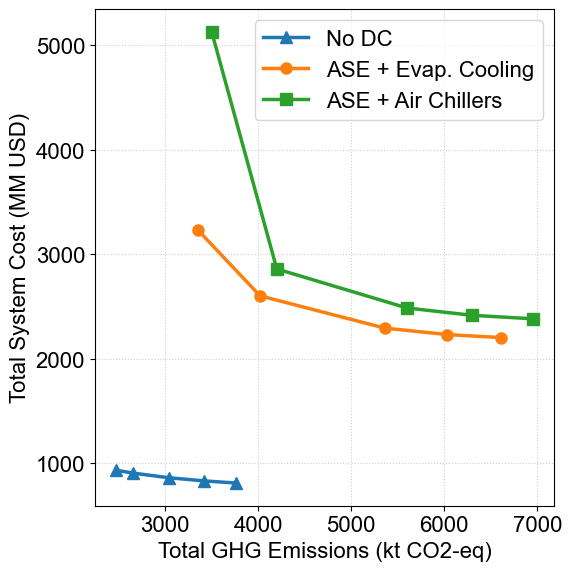

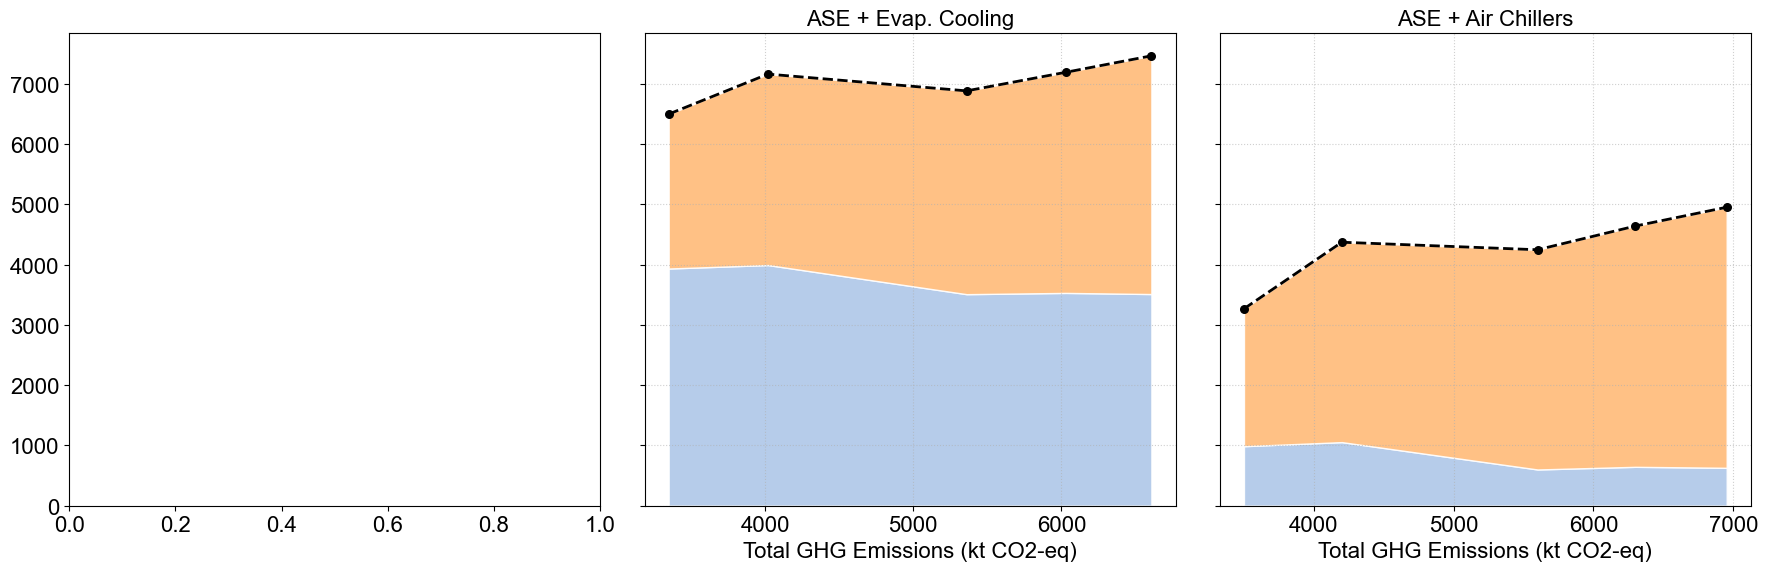

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
# Easily change any font size here!
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 16,
    "title_size"    => 16,  # Size for plot titles
    "axis_label"    => 16,  # Size for X and Y axis text
    "tick_label"    => 16,  # Size for numbers on the axes
    "legend_size"   => 16   # Size for legend text
)

# Apply Plotting Styles globally
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# Define the 3 Cases with their specific paths, files, and assigned colors
cases = [
    ("No DC", "../Emission_Cost_Pareto_Case_No_DC/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_2_90pct.xlsx",
        "Results_Pareto_3_80pct.xlsx",
        "Results_Pareto_4_70pct.xlsx",
        "Results_Pareto_5_65pct.xlsx"
    ], "#1f77b4", "^"), # Blue, Triangle

    ("ASE + Evap. Cooling", "./", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#ff7f0e", "o"), # Orange, Circle

    ("ASE + Air Chillers", "../Emission_Cost_Pareto_Case_6/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx"
    ], "#2ca02c", "s")  # Green, Square
]

# Dictionary to store the extracted data for each case
results_data = Dict{String, DataFrame}()

# ==========================================
# 2. Data Extraction Logic
# ==========================================
println(">>> Processing files for all cases...")

for (case_name, dir_path, fnames, color, marker) in cases
    df_results = DataFrame(
        Emissions = Float64[], 
        Cost = Float64[], 
        Water_Total = Float64[], 
        Water_Direct = Float64[], 
        Water_Indirect = Float64[]
    )
    
    println("\n-> Extracting: $case_name")
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        if !isfile(filepath)
            println("   ⚠️ Warning: File not found: $filepath")
            continue
        end

        xf = XLSX.readxlsx(filepath)

        # --- A. EMISSIONS ---
        sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
        
        val_emi = !isnothing(total_row_idx) ? 
            (sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]) : 
            (sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4]))

        # --- B. COSTS ---
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        
        val_cost = !isnothing(total_row_cost_idx) ? 
            (sh_cost[total_row_cost_idx, 2] + sh_cost[total_row_cost_idx, 3] + sh_cost[total_row_cost_idx, 4] + sh_cost[total_row_cost_idx, 5]) : 
            (sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + sum(sh_cost[!, 4]) + sum(sh_cost[!, 5]))

        # --- C. WATER ---
        sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        
        function get_col_sum(df, name_part)
            c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
            return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
        end

        val_indirect = get_col_sum(sh_water, "Grid_Indirect")
        direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
        val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
        
        push!(df_results, (val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    end
    
    # Sort Ascending by Emissions (Crucial for proper stackplot and line plotting)
    sort!(df_results, :Emissions)
    results_data[case_name] = df_results
end

# ==========================================
# 3. Find Global Max for Water Y-Axis
# ==========================================
global_max_water = 0.0
for (case_name, df) in results_data
    if nrow(df) > 0
        global_max_water = max(global_max_water, maximum(df.Water_Total))
    end
end
water_ylim_max = global_max_water * 1.05

# ==========================================
# 4. PLOTTING FIGURE 1: 1x1 Pareto Front
# ==========================================
fig1, ax_pareto = PyPlot.subplots(1, 1, figsize=(6, 6))

for (case_name, _, _, color, marker) in cases
    if haskey(results_data, case_name) && nrow(results_data[case_name]) > 0
        df = results_data[case_name]
        ax_pareto.plot(df.Emissions, df.Cost, marker=marker, linestyle="-", 
                       color=color, markersize=8, linewidth=2.5, label=case_name)
    end
end

# ax_pareto.set_title("Combined Pareto Front: Cost vs. Emissions", fontweight="bold")
ax_pareto.set_xlabel("Total GHG Emissions (kt CO2-eq)")
ax_pareto.set_ylabel("Total System Cost (MM USD)")
ax_pareto.legend(loc="upper right")
ax_pareto.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
savefig("abstract_Pareto_Front.pdf", dpi=600, bbox_inches="tight")
display(fig1)

# ==========================================
# 5. PLOTTING FIGURE 2: 1x3 Water Trade-offs
# ==========================================
# sharey=true ensures the Y-axis limits match automatically and removes redundant axis text
fig2, axs_water = PyPlot.subplots(1, 3, figsize=(18, 6), sharey=true)

# Helper function for the 1x3 water plots (Added `show_legend` argument)
function plot_water_tradeoff!(ax, case_name, df, y_max, show_ylabel=false, show_legend=false)
    if nrow(df) == 0; return; end
    
    ax.stackplot(df.Emissions, df.Water_Direct, df.Water_Indirect, 
                 labels=["Direct Water", "Indirect Water"], colors=["#aec7e8", "#ffbb78"], alpha=0.9, edgecolor="white")
                 
    ax.plot(df.Emissions, df.Water_Total, color="black", linestyle="--", linewidth=2, label="Total Water")
    ax.scatter(df.Emissions, df.Water_Total, color="black", s=30, zorder=5)

    ax.set_title(case_name)
    ax.set_xlabel("Total GHG Emissions (kt CO2-eq)")
    
    # Only label the Y-axis on the leftmost plot
    if show_ylabel
        ax.set_ylabel("Water Consumption (MMGal)")
    end
    
    ax.set_ylim(0, y_max)
    
    # Only draw the legend if show_legend is true
    if show_legend
        ax.legend(loc="upper left")
    end
    
    ax.grid(true, linestyle=":", alpha=0.6)
end

# Plot each case into the 1x3 grid
# Arguments: axis, name, dataframe, y_max, show_ylabel, show_legend
plot_water_tradeoff!(axs_water[1], cases[1][1], results_data[cases[1][1]], water_ylim_max, true, true)    # No DC (Show Y-label & Legend)
plot_water_tradeoff!(axs_water[2], cases[2][1], results_data[cases[2][1]], water_ylim_max, false, false)  # ASE + Evap (Hide both)
plot_water_tradeoff!(axs_water[3], cases[3][1], results_data[cases[3][1]], water_ylim_max, false, false)  # ASE + Air (Hide both)

# Set a super title for the entire 1x3 figure
# fig2.suptitle("Water-Carbon Trade-off Across Scenarios", fontweight="bold", fontsize=style["title_size"] + 2, y=1.05)

PyPlot.tight_layout()
# savefig("Figure_2_Water_Tradeoffs_1x3.png", dpi=600, bbox_inches="tight")
display(fig2)

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Setup
# ==========================================
# Apply Plotting Styles
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 12,
    "title_size"    => 14,
    "axis_label"    => 12
)
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])

# Define the 3 Cases with their specific paths, files, and assigned colors
cases = [
    ("No DC", "../Emission_Cost_Pareto_Case_No_DC/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_2_90pct.xlsx",
        "Results_Pareto_3_80pct.xlsx",
        "Results_Pareto_4_70pct.xlsx",
        "Results_Pareto_5_65pct.xlsx"
    ], "#1f77b4", "^"), # Blue, Triangle

    ("ASE + Evap. Cooling", "./", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx",
        # "Results_Pareto_1_45pct.xlsx"
    ], "#ff7f0e", "o"), # Orange, Circle

    ("ASE + Air Chillers", "../Emission_Cost_Pareto_Case_6/", [
        "Results_Pareto_1_100pct.xlsx",
        "Results_Pareto_1_90pct.xlsx",
        "Results_Pareto_2_80pct.xlsx",
        "Results_Pareto_3_60pct.xlsx",
        "Results_Pareto_4_50pct.xlsx",
        # "Results_Pareto_1_45pct.xlsx"
    ], "#2ca02c", "s")  # Green, Square
]

# Dictionary to store the extracted data for each case
results_data = Dict{String, DataFrame}()

# ==========================================
# 2. Data Extraction Logic
# ==========================================
println(">>> Processing files for all cases...")

for (case_name, dir_path, fnames, color, marker) in cases
    df_results = DataFrame(
        Emissions = Float64[], 
        Cost = Float64[], 
        Water_Total = Float64[], 
        Water_Direct = Float64[], 
        Water_Indirect = Float64[]
    )
    
    println("\n-> Extracting: $case_name")
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        if !isfile(filepath)
            println("   ⚠️ Warning: File not found: $filepath")
            continue
        end

        xf = XLSX.readxlsx(filepath)

        # --- A. EMISSIONS ---
        sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
        
        val_emi = 0.0
        if !isnothing(total_row_idx)
            val_emi = sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]
        else
            val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
        end

        # --- B. COSTS ---
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        
        val_cost = 0.0
        if !isnothing(total_row_cost_idx)
            val_cost = sh_cost[total_row_cost_idx, 2] + sh_cost[total_row_cost_idx, 3] + 
                       sh_cost[total_row_cost_idx, 4] + sh_cost[total_row_cost_idx, 5]
        else
            val_cost = sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + 
                       sum(sh_cost[!, 4]) + sum(sh_cost[!, 5])
        end

        # --- C. WATER ---
        sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        
        function get_col_sum(df, name_part)
            c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
            return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
        end

        val_indirect = get_col_sum(sh_water, "Grid_Indirect")
        direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
        val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
        
        push!(df_results, (val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    end
    
    # Sort Ascending by Emissions (Crucial for proper stackplot and line plotting)
    sort!(df_results, :Emissions)
    results_data[case_name] = df_results
end

# ==========================================
# 3. Find Global Max for Water Y-Axis
# ==========================================
global_max_water = 0.0
for (case_name, df) in results_data
    if nrow(df) > 0
        case_max = maximum(df.Water_Total)
        if case_max > global_max_water
            global_max_water = case_max
        end
    end
end
# Add a 15% buffer above the absolute maximum point so it doesn't clip the top border
water_ylim_max = global_max_water * 1.05

# ==========================================
# 4. Plotting (2x2 Grid)
# ==========================================
fig, axs = PyPlot.subplots(2, 2, figsize=(12, 12))

# Flatten axes for easy reference
ax_pareto = axs[1, 1]
ax_w1 = axs[1, 2] # Water: No DC
ax_w2 = axs[2, 1] # Water: ASE + Evap
ax_w3 = axs[2, 2] # Water: ASE + Air

# --- PLOT 1: COMBINED PARETO FRONT ---
for (case_name, _, _, color, marker) in cases
    if haskey(results_data, case_name) && nrow(results_data[case_name]) > 0
        df = results_data[case_name]
        ax_pareto.plot(df.Emissions, df.Cost, marker=marker, linestyle="-", 
                       color=color, markersize=8, linewidth=2.5, label=case_name)
    end
end
ax_pareto.set_title("Combined Pareto Front: Cost vs. Emissions", fontsize=16, fontweight="bold")
ax_pareto.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)
ax_pareto.set_ylabel("Total System Cost (MM USD)", fontsize=12)
ax_pareto.legend(loc="upper right")
ax_pareto.grid(true, linestyle=":", alpha=0.6)

# --- HELPER FUNCTION FOR WATER PLOTS ---
# Notice we added `y_max` as an argument here
function plot_water_tradeoff!(ax, case_name, df, y_max)
    if nrow(df) == 0; return; end
    
    # Stackplot requires x to be strictly increasing, which we handled with sort! earlier
    ax.stackplot(df.Emissions, df.Water_Direct, df.Water_Indirect, 
                 labels=["Direct Water", "Indirect Water"], colors=["#aec7e8", "#ffbb78"], alpha=0.9, edgecolor="white")
                 
    ax.plot(df.Emissions, df.Water_Total, color="black", linestyle="--", linewidth=2, label="Total Water")
    ax.scatter(df.Emissions, df.Water_Total, color="black", s=30, zorder=5)

    ax.set_title("Water-Carbon Trade-off: $case_name", fontsize=14)
    ax.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)
    ax.set_ylabel("Water Consumption (MMGal)", fontsize=12)
    
    # ENFORCE THE GLOBAL Y-AXIS LIMIT HERE
    ax.set_ylim(0, y_max)
    
    ax.legend(loc="upper left")
    ax.grid(true, linestyle=":", alpha=0.6)
end

# --- PLOT 2, 3, 4: WATER TRADE-OFFS ---
# Pass the global limit into each function call
plot_water_tradeoff!(ax_w1, cases[1][1], results_data[cases[1][1]], water_ylim_max) # No DC
plot_water_tradeoff!(ax_w2, cases[2][1], results_data[cases[2][1]], water_ylim_max) # ASE + Evap
plot_water_tradeoff!(ax_w3, cases[3][1], results_data[cases[3][1]], water_ylim_max) # ASE + Air

PyPlot.tight_layout(pad=2.0)
display(fig)

In [ ]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration
# ==========================================
# Updated file names based on the VS Code explorer image
# Removed '%' from the labels as requested
files_info = [
    (1, "100", "Results_Pareto_1_100pct.xlsx"),
    (2, "90",  "Results_Pareto_1_90pct.xlsx"),
    (3, "80",  "Results_Pareto_2_80pct.xlsx"),
    (4, "60",  "Results_Pareto_3_60pct.xlsx"),
    (5, "50",  "Results_Pareto_4_50pct.xlsx"),
    # (6, "45",  "Results_Pareto_1_45pct.xlsx")
]

df_results = DataFrame(
    Label = String[], 
    Emissions = Float64[], 
    Cost = Float64[], 
    Water_Total = Float64[], 
    Water_Direct = Float64[], 
    Water_Indirect = Float64[]
)

println(">>> Processing files...")

# ==========================================
# 2. Data Extraction
# ==========================================
for (case_num, label, fname) in files_info
    if !isfile(fname)
        println("⚠️ Warning: File not found: $fname")
        continue
    end

    xf = XLSX.readxlsx(fname)

    # -------------------------------------------------------
    # A. EMISSIONS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, and 4 to get Total Emissions (Man + Op + Dec).
    sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
    
    # Find "Total" row index
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]
    else
        # Fallback: Sum entire columns
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # -------------------------------------------------------
    # B. COSTS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, 4, and 5 (Inv + FixOM + VarOM + Dec)
    sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
    total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
    
    val_cost = 0.0
    if !isnothing(total_row_cost_idx)
        val_cost = sh_cost[total_row_cost_idx, 2] + 
                   sh_cost[total_row_cost_idx, 3] + 
                   sh_cost[total_row_cost_idx, 4] + 
                   sh_cost[total_row_cost_idx, 5]
    else
        val_cost = sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + 
                   sum(sh_cost[!, 4]) + sum(sh_cost[!, 5])
    end

    # -------------------------------------------------------
    # C. WATER (Name Matching)
    # -------------------------------------------------------
    # Values in these files are already in MMGal thanks to the new Results.jl
    sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # Helper to find column index by partial string match (handles new MMGal headers automatically)
    function get_col_sum(df, name_part)
        c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
        return isnothing(c) ? 0.0 : sum(df[!, c])
    end

    val_indirect = get_col_sum(sh_water, "Grid_Indirect")
    
    direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
    
    push!(df_results, (label, val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    println("   -> Loaded $fname | Cost: $(round(val_cost, digits=1)) | Emi: $(round(val_emi, digits=1)) | Total Water: $(round(val_direct + val_indirect, digits=1)) MMGal")
end

# Sort Descending (High Emission -> Low Emission)
sort!(df_results, :Emissions, rev=true)

# ==========================================
# 3. Plotting
# ==========================================
fig, (ax1, ax2) = PyPlot.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Pareto ---
ax1.plot(df_results.Emissions, df_results.Cost, marker="o", linestyle="--", color="b", markersize=8)
# for i in 1:nrow(df_results)
#     ax1.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Cost[i]), 
#                  xytext=(5, 5), textcoords="offset points", fontweight="bold")
# end
ax1.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)
ax1.set_ylabel("Total System Cost (MM USD)", fontsize=12)
ax1.set_title("Pareto Front: Cost vs. Emissions", fontsize=14)
ax1.grid(true, linestyle=":", alpha=0.6)

# --- Plot 2: Water Trade-off ---
ax2.stackplot(df_results.Emissions, df_results.Water_Direct, df_results.Water_Indirect, 
              labels=["Direct Water", "Indirect Water"], colors=["#2ca02c", "#1f77b4"], alpha=0.7)
ax2.plot(df_results.Emissions, df_results.Water_Total, color="k", linestyle="--", linewidth=1, label="Total Water")
ax2.scatter(df_results.Emissions, df_results.Water_Total, color="k", s=20)

# for i in 1:nrow(df_results)
#     ax2.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Water_Total[i]), 
#                  xytext=(0, 10), textcoords="offset points", ha="center")
# end
ax2.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)

# UPDATED: Y-axis label explicitly states MMGal
ax2.set_ylabel("Water Consumption (MMGal)", fontsize=12)
ax2.set_title("Water-Carbon Trade-off", fontsize=14)
ax2.legend(loc="upper left")
ax2.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
display(fig)

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Setup
# ==========================================
# Assuming standard Model_Data.xlsx is in the same directory
model_data_path = "Model_Data.xlsx"

# Define the cases, their respective folder paths, and their specific file names
cases = Dict(
    "Case 1" => Dict(
        :path => "./",
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_1_90pct.xlsx",
            "Results_Pareto_2_80pct.xlsx",
            "Results_Pareto_3_60pct.xlsx",
            "Results_Pareto_4_50pct.xlsx",
            "Results_Pareto_1_45pct.xlsx",
        ]
    ),
    "Case 6" => Dict(
        :path => "../Emission_Cost_Pareto_Case_6/", # <-- Adjust if needed
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_1_90pct.xlsx",
            "Results_Pareto_2_80pct.xlsx",
            "Results_Pareto_3_60pct.xlsx",
            "Results_Pareto_4_50pct.xlsx",
            "Results_Pareto_1_45pct.xlsx"
        ]
    ),
    "No DC" => Dict(
        :path => "../Emission_Cost_Pareto_Case_No_DC/", # <-- Adjust if needed
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_2_90pct.xlsx",
            "Results_Pareto_3_80pct.xlsx",
            "Results_Pareto_4_70pct.xlsx",
            "Results_Pareto_5_65pct.xlsx"
        ]
    )
)

println(">>> Loading Availability Factors from Model_Data.xlsx...")

# ==========================================
# 2. Extract Availability from Model_Data
# ==========================================
xf_model = XLSX.readxlsx(model_data_path)

# A. Read PT (Performance Loss) and cap_t (Turbine Capacity)
df_mod = DataFrame(XLSX.gettable(xf_model["Model_Data"]))
PT = Dict{String, Float64}()
cap_t = Dict{String, Float64}()

for row in eachrow(df_mod)
    param = String(row.Parameter)
    tech = lowercase(String(row.Technology))
    if param == "PT"
        PT[tech] = Float64(row.Value)
    elseif param == "cap_t"
        cap_t[tech] = Float64(row.Value)
    end
end

# B. Read Annual Sums of HL (Solar Load Factor) and WP (Wind Power)
function get_annual_sums(sheet_name)
    df = DataFrame(XLSX.gettable(xf_model[sheet_name]))
    sums = Dict{Int, Float64}()
    for col in names(df)
        col_str = String(col)
        if col_str != "hours" && col_str != "Hour"
            y = parse(Int, col_str)
            sums[y] = sum(coalesce.(df[!, col], 0.0))
        end
    end
    return sums
end

sum_hl = get_annual_sums("HL")
sum_wp = get_annual_sums("WP")

# ==========================================
# 3. Data Extraction Logic
# ==========================================
function get_emissions_and_curtailment(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0)
    end
    
    xf_res = XLSX.readxlsx(filepath)
    
    # --- 1. Total Emissions ---
    sh_emi = DataFrame(XLSX.gettable(xf_res["Emissions_summary"]))
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = Float64(sh_emi[total_row_idx, 2]) + Float64(sh_emi[total_row_idx, 3]) + Float64(sh_emi[total_row_idx, 4])
    else
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # --- 2. Average Yearly Curtailment ---
    df_gen = DataFrame(XLSX.gettable(xf_res["Generation_Summary"]))
    df_cap = DataFrame(XLSX.gettable(xf_res["Capacity_Exp_Dec"]))
    
    # Exclude the 2025 initialization year
    filter!(row -> row.Year != 2025, df_gen)
    filter!(row -> row.Year != 2025, df_cap)
    
    n_years = nrow(df_gen)
    if n_years == 0; return (val_emi, 0.0); end
    
    total_curtailment_all_years = 0.0
    
    for i in 1:n_years
        y = Int(df_gen[i, :Year])
        
        for tech_col in names(df_gen)
            if String(tech_col) in ["Year", "Grid", "Grid_Energy_MWh"]
                continue
            end
            
            t = String(tech_col)
            t_lower = lowercase(t)
            
            is_solar = occursin("pv", t_lower) || occursin("solar", t_lower)
            is_wind = occursin("wt", t_lower) || occursin("wind", t_lower)
            
            if !is_solar && !is_wind
                continue 
            end
            
            gen_gwh = Float64(df_gen[i, tech_col])
            
            cap_col = Symbol("$t Cap")
            cap_val = hasproperty(df_cap, cap_col) ? Float64(df_cap[i, cap_col]) : 0.0
            
            avail_mwh = 0.0
            if is_solar
                pt_val = get(PT, t_lower, 0.0)
                avail_mwh = cap_val * get(sum_hl, y, 0.0) * (1 - pt_val)
            elseif is_wind
                capt_val = get(cap_t, t_lower, 1.0)
                turbines = cap_val / capt_val
                avail_mwh = turbines * get(sum_wp, y, 0.0)
            end
            
            avail_gwh = avail_mwh / 1000.0
            curt_gwh = max(0.0, avail_gwh - gen_gwh)
            total_curtailment_all_years += curt_gwh
        end
    end
    
    avg_curtailment = total_curtailment_all_years / n_years
    avg_yearly_emi = val_emi / n_years # Yearly average emissions
    
    return (avg_yearly_emi, avg_curtailment)
end

# Extract data for all cases
results_data = Dict{String, Vector{Tuple{Float64, Float64}}}()

for (case_name, case_info) in cases
    println("\n>>> Processing files for $case_name...")
    pts = Tuple{Float64, Float64}[]
    
    dir_path = case_info[:path]
    fnames = case_info[:files]
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        emi, curt = get_emissions_and_curtailment(filepath)
        if emi > 0.0
            push!(pts, (emi, curt))
            println("   -> Extracted: EMI = $(round(emi, digits=1)) kt/yr | Curtailment = $(round(curt, digits=1)) GWh/yr")
        end
    end
    
    # Sort points from Lowest Emission to Highest Emission (ASCENDING order)
    sort!(pts, by = x -> x[1]) 
    results_data[case_name] = pts
end

# ==========================================
# 4. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(6, 8))

plot_styles = Dict(
    "Case 1" => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "Case 6" => Dict(:color => "#1f77b4", :marker => "s"), # Blue 
    "No DC"  => Dict(:color => "#2ca02c", :marker => "^")  # Green
)

# A. Draw the lines and markers
for (case_name, pts) in results_data
    if isempty(pts); continue; end
    style = plot_styles[case_name]
    
    x_vals = [p[1] for p in pts]
    y_vals = [p[2] for p in pts]
    
    ax.plot(x_vals, y_vals, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)
end

# B. DYNAMIC TEXT ANNOTATION FOR CASE 1 & CASE 6
if haskey(results_data, "Case 1") && haskey(results_data, "Case 6")
    pts_1 = results_data["Case 1"]
    pts_6 = results_data["Case 6"]
    
    # They both have 6 points, loop through them index-by-index
    n_pts = min(length(pts_1), length(pts_6))
    for i in 1:n_pts
        x1, y1 = pts_1[i]
        x6, y6 = pts_6[i]
        
        # Whichever point is higher goes UP, the other goes DOWN
        if y1 >= y6
            off1, va1 = (0, 10), "bottom"
            off6, va6 = (0, -12), "top"
        else
            off1, va1 = (0, -12), "top"
            off6, va6 = (0, 10), "bottom"
        end
        
        # Annotate Case 1
        ax.annotate(string(round(y1, digits=0)), xy=(x1, y1), xytext=off1, textcoords="offset points", 
                    ha="center", va=va1, fontsize=10, fontweight="bold", color=plot_styles["Case 1"][:color])
                    
        # Annotate Case 6
        ax.annotate(string(round(y6, digits=0)), xy=(x6, y6), xytext=off6, textcoords="offset points", 
                    ha="center", va=va6, fontsize=10, fontweight="bold", color=plot_styles["Case 6"][:color])
    end
end

# C. STATIC TEXT ANNOTATION FOR NO DC
if haskey(results_data, "No DC")
    for (x, y) in results_data["No DC"]
        # Pushing text cleanly UP so it doesn't cross its own downward line
        ax.annotate(string(round(y, digits=0)), xy=(x, y), xytext=(0, 10), textcoords="offset points", 
                    ha="center", va="bottom", fontsize=10, fontweight="bold", color=plot_styles["No DC"][:color])
    end
end

ax.set_title("Total Average Yearly Emissions vs. Average Yearly Curtailed Energy", fontsize=14)
ax.set_xlabel("Total Average Yearly GHG Emissions (kt CO2-eq / yr)", fontsize=12)
ax.set_ylabel("Avg Yearly Curtailed Energy (GWh)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

ax.legend(loc="upper right")

PyPlot.tight_layout()
display(fig)

In [ ]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Setup
# ==========================================

# Define the cases, their respective folder paths, and their specific file names
cases = Dict(
    "Case 1" => Dict(
        :path => "./",
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_1_90pct.xlsx",
            "Results_Pareto_2_80pct.xlsx",
            "Results_Pareto_3_60pct.xlsx",
            "Results_Pareto_4_50pct.xlsx",
            "Results_Pareto_1_45pct.xlsx"
        ]
    ),
    "Case 6" => Dict(
        :path => "../Emission_Cost_Pareto_Case_6/", # <-- Adjust if needed
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_1_90pct.xlsx",
            "Results_Pareto_2_80pct.xlsx",
            "Results_Pareto_3_60pct.xlsx",
            "Results_Pareto_4_50pct.xlsx",
            "Results_Pareto_1_45pct.xlsx"
        ]
    ),
    "No DC" => Dict(
        :path => "../Emission_Cost_Pareto_Case_No_DC/", # <-- Adjust if needed
        :files => [
            "Results_Pareto_1_100pct.xlsx",
            "Results_Pareto_2_90pct.xlsx",
            "Results_Pareto_3_80pct.xlsx",
            "Results_Pareto_4_70pct.xlsx",
            "Results_Pareto_5_65pct.xlsx"
        ]
    )
)

println(">>> Extracting Exact Solver Outputs...")

# ==========================================
# 2. Data Extraction Logic (Strictly Real Output)
# ==========================================
function get_emissions_and_actual_vres(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0)
    end
    
    xf_res = XLSX.readxlsx(filepath)
    
    # --- 1. Total Emissions (Real Output) ---
    sh_emi = DataFrame(XLSX.gettable(xf_res["Emissions_summary"]))
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = Float64(sh_emi[total_row_idx, 2]) + Float64(sh_emi[total_row_idx, 3]) + Float64(sh_emi[total_row_idx, 4])
    else
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # --- 2. Actual Renewable Generation (Real Output) ---
    df_gen = DataFrame(XLSX.gettable(xf_res["Generation_Summary"]))
    
    # Exclude the 2025 initialization year
    filter!(row -> row.Year != 2025, df_gen)
    
    n_years = nrow(df_gen)
    if n_years == 0; return (val_emi, 0.0); end
    
    total_vres_all_years = 0.0
    
    for i in 1:n_years
        for tech_col in names(df_gen)
            if String(tech_col) in ["Year", "Grid", "Grid_Energy_MWh"]
                continue
            end
            
            t_lower = lowercase(String(tech_col))
            
            # Sum ONLY the real generation from Wind and Solar variables
            is_solar = occursin("pv", t_lower) || occursin("solar", t_lower)
            is_wind = occursin("wt", t_lower) || occursin("wind", t_lower)
            
            if is_solar || is_wind
                # The generation summary values are exactly what the solver chose (in GWh)
                total_vres_all_years += Float64(df_gen[i, tech_col])
            end
        end
    end
    
    avg_yearly_vres = total_vres_all_years / n_years
    avg_yearly_emi = val_emi / n_years 
    
    return (avg_yearly_emi, avg_yearly_vres)
end

# Extract data for all cases
results_data = Dict{String, Vector{Tuple{Float64, Float64}}}()

for (case_name, case_info) in cases
    println("\n>>> Processing files for $case_name...")
    pts = Tuple{Float64, Float64}[]
    
    dir_path = case_info[:path]
    fnames = case_info[:files]
    
    for fname in fnames
        filepath = joinpath(dir_path, fname)
        emi, vres_gen = get_emissions_and_actual_vres(filepath)
        if emi > 0.0
            push!(pts, (emi, vres_gen))
            println("   -> Extracted: EMI = $(round(emi, digits=1)) kt/yr | Actual VRES Gen = $(round(vres_gen, digits=1)) GWh/yr")
        end
    end
    
    # Sort points from Lowest Emission to Highest Emission (ASCENDING order)
    sort!(pts, by = x -> x[1]) 
    results_data[case_name] = pts
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(6, 8))

plot_styles = Dict(
    "Case 1" => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "Case 6" => Dict(:color => "#1f77b4", :marker => "s"), # Blue 
    "No DC"  => Dict(:color => "#2ca02c", :marker => "^")  # Green
)

# A. Draw the lines and markers
for (case_name, pts) in results_data
    if isempty(pts); continue; end
    style = plot_styles[case_name]
    
    x_vals = [p[1] for p in pts]
    y_vals = [p[2] for p in pts]
    
    # Plot line
    ax.plot(x_vals, y_vals, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)
end

# B. DYNAMIC TEXT ANNOTATION FOR CASE 1 & CASE 6
if haskey(results_data, "Case 1") && haskey(results_data, "Case 6")
    pts_1 = results_data["Case 1"]
    pts_6 = results_data["Case 6"]
    
    # They both have 6 points, loop through them index-by-index
    n_pts = min(length(pts_1), length(pts_6))
    for i in 1:n_pts
        x1, y1 = pts_1[i]
        x6, y6 = pts_6[i]
        
        # Whichever point is higher goes UP, the other goes DOWN
        if y1 >= y6
            off1, va1 = (0, 10), "bottom"
            off6, va6 = (0, -12), "top"
        else
            off1, va1 = (0, -12), "top"
            off6, va6 = (0, 10), "bottom"
        end
        
        # Annotate Case 1
        ax.annotate(string(round(y1, digits=0)), xy=(x1, y1), xytext=off1, textcoords="offset points", 
                    ha="center", va=va1, fontsize=10, fontweight="bold", color=plot_styles["Case 1"][:color])
                    
        # Annotate Case 6
        ax.annotate(string(round(y6, digits=0)), xy=(x6, y6), xytext=off6, textcoords="offset points", 
                    ha="center", va=va6, fontsize=10, fontweight="bold", color=plot_styles["Case 6"][:color])
    end
end

# C. STATIC TEXT ANNOTATION FOR NO DC
if haskey(results_data, "No DC")
    for (x, y) in results_data["No DC"]
        # Pushing text cleanly UP so it doesn't cross its own downward line
        ax.annotate(string(round(y, digits=0)), xy=(x, y), xytext=(0, 10), textcoords="offset points", 
                    ha="center", va="bottom", fontsize=10, fontweight="bold", color=plot_styles["No DC"][:color])
    end
end

ax.set_title("Total Average Yearly Emissions vs. Actual Yearly Renewable Generation", fontsize=14)
ax.set_xlabel("Total Average Yearly GHG Emissions (kt CO2-eq / yr)", fontsize=12)
ax.set_ylabel("Actual Yearly VRES Generation (GWh)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

ax.legend(loc="upper right")

PyPlot.tight_layout()
display(fig)